<a href="https://colab.research.google.com/github/GreeshmaBodapati/Data-visualization-/blob/main/Student_Performance_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Student Performance Prediction Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [4]:
# UPDATE THIS PATH FOR YOUR GOOGLE DRIVE/COLAB
path ="/Students_Grading_Dataset (1).csv"
df = pd.read_csv(path)

In [5]:
print(df.head())

  Student_ID First_Name Last_Name                    Email  Gender  Age  \
0      S1000       Omar  Williams  student0@university.com  Female   22   
1      S1001      Maria     Brown  student1@university.com    Male   18   
2      S1002      Ahmed     Jones  student2@university.com    Male   24   
3      S1003       Omar  Williams  student3@university.com  Female   24   
4      S1004       John     Smith  student4@university.com  Female   23   

    Department  Attendance (%)  Midterm_Score  Final_Score  ...  \
0  Engineering           52.29          55.03        57.82  ...   
1  Engineering           97.27          97.23        45.80  ...   
2     Business           57.19          67.05        93.68  ...   
3  Mathematics           95.15          47.79        80.63  ...   
4           CS           54.18          46.59        78.89  ...   

   Projects_Score  Total_Score  Grade  Study_Hours_per_Week  \
0           85.90        56.09      F                   6.2   
1           55.65   

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [7]:
print(df.describe())

               Age  Attendance (%)  Midterm_Score  Final_Score  \
count  5000.000000     4484.000000    5000.000000  5000.000000   
mean     21.048400       75.431409      70.326844    69.640788   
std       1.989786       14.372446      17.213209    17.238744   
min      18.000000       50.010000      40.000000    40.000000   
25%      19.000000       63.265000      55.457500    54.667500   
50%      21.000000       75.725000      70.510000    69.735000   
75%      23.000000       87.472500      84.970000    84.500000   
max      24.000000      100.000000      99.980000    99.980000   

       Assignments_Avg  Quizzes_Avg  Participation_Score  Projects_Score  \
count      4483.000000  5000.000000          5000.000000     5000.000000   
mean         74.798673    74.910728             4.980024       74.924860   
std          14.411799    14.504281             2.890136       14.423415   
min          50.000000    50.030000             0.000000       50.010000   
25%          62.090000   

In [8]:
print(df.isnull().sum())

Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64


In [9]:
df = df.dropna()

In [10]:
sid = int(input("Enter Student ID: "))
student = df[df["Student_ID"] == sid]
print(student if not student.empty else "Student not found")

Enter Student ID: 12345
Student not found


In [11]:
dept = input("Enter Department: ")
print(df[df["Department"].astype(str).str.lower()==dept.lower()])

Enter Department: 6789
Empty DataFrame
Columns: [Student_ID, First_Name, Last_Name, Email, Gender, Age, Department, Attendance (%), Midterm_Score, Final_Score, Assignments_Avg, Quizzes_Avg, Participation_Score, Projects_Score, Total_Score, Grade, Study_Hours_per_Week, Extracurricular_Activities, Internet_Access_at_Home, Parent_Education_Level, Family_Income_Level, Stress_Level (1-10), Sleep_Hours_per_Night]
Index: []

[0 rows x 23 columns]


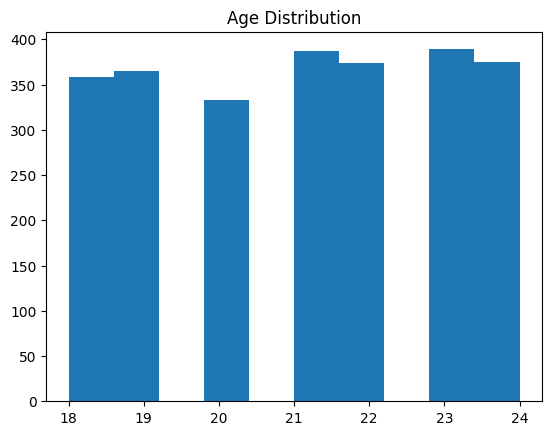

In [12]:
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.show()

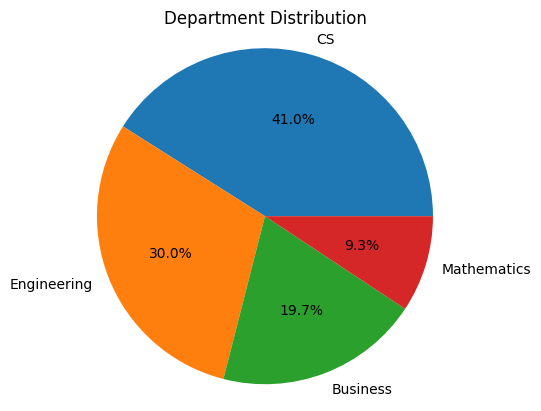

In [13]:
dept_counts=df["Department"].value_counts()
plt.pie(dept_counts.values, labels=dept_counts.index, autopct="%1.1f%%")
plt.title("Department Distribution")
plt.axis("equal")
plt.show()

In [14]:
X=df[["Midterm_Score","Attendance (%)","Study_Hours_per_Week"]]
y=df["Final_Score"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)

In [15]:
print("MAE:",mean_absolute_error(y_test,pred))
print("MSE:",mean_squared_error(y_test,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
print("R2:",r2_score(y_test,pred))

MAE: 14.985357775980775
MSE: 295.0647819985591
RMSE: 17.177449810683747
R2: 5.322813290042916e-05


In [16]:
mid=float(input("Midterm Score: "))
att=float(input("Attendance (%): "))
hrs=float(input("Study Hours/Week: "))

Midterm Score: 256
Attendance (%): 89
Study Hours/Week: 789


Predicted Final Score: 52.8


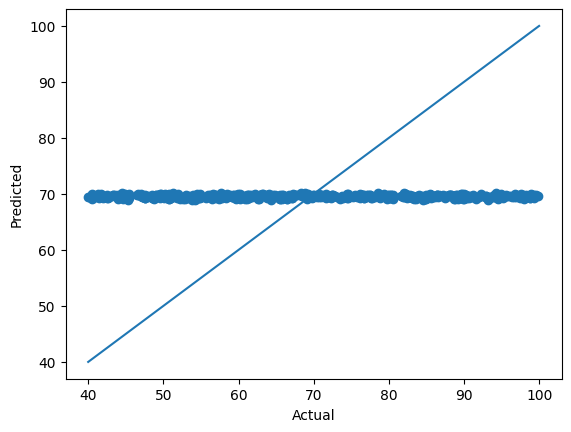

In [17]:
sample=pd.DataFrame([[mid,att,hrs]],columns=X.columns)
final=model.predict(sample)[0]
print("Predicted Final Score:",round(final,2))
plt.scatter(y_test,pred)
plt.plot([y.min(),y.max()],[y.min(),y.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [18]:
joblib.dump(model,"student_performance_model.pkl")
print("Model saved.")

Model saved.
